In [13]:
cd /content/drive/MyDrive/projects/Nadir/

/content/drive/MyDrive/projects/Nadir


In [14]:
# Standard Library
import os
import tempfile

# Third-Party (Math, ML, and Video)
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import numpy as np
import torch
from tqdm import tqdm
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
from torchvision.transforms import Resize
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
import matplotlib.animation as animation
from IPython.display import HTML
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.gridspec as gridspec
from sklearn.metrics.pairwise import cosine_similarity

# Environment Specific
from google.colab import userdata

In [15]:
def var_exp(y, y_):
  tot_var = y.var() + 1e-6
  res_var = (y - y_).var()
  return 1 - res_var / tot_var

In [32]:
# get data
data_path = '/content/drive/MyDrive/projects/data/dsprites-dataset/dsprites.npz'

# load the data
import numpy as np
data = np.load(data_path, allow_pickle=True, encoding="latin1")
for key in data.keys():
  print(key, data[key].shape)

images = data['imgs'].copy()
print(images.dtype, images.min(), images.max())
targets = data['latents_classes'].copy()
print(targets.dtype, targets.min(0), targets.max(0))

metadata ()
imgs (737280, 64, 64)
latents_classes (737280, 6)
latents_values (737280, 6)
uint8 0 1
int64 [0 0 0 0 0 0] [ 0  2  5 39 31 31]


In [33]:
# get specific
ind_shape = targets[:, 1] == 2
# ind_size = targets[:, 2] == 5
ind_size = targets[:, 2] % 1 == 0
ind_good = np.logical_and(ind_shape, ind_size)
ind_rot = targets[:, 3] == 0
# ind_rot = targets[:, 3] % 1 == 0
ind_good = np.logical_and(ind_good, ind_rot)
ind_x = targets[:, 4] % 1 == 0
# ind_x = targets[:, 4] == 0
ind_good = np.logical_and(ind_good, ind_x)
ind_y = targets[:, 5] % 1 == 0
# ind_y = targets[:, 5] % 1 == 0
# ind_y = targets[:, 5] == 0
ind_good = np.logical_and(ind_good, ind_y)
np.sum(ind_good), targets[ind_good]

(np.int64(6144),
 array([[ 0,  2,  0,  0,  0,  0],
        [ 0,  2,  0,  0,  0,  1],
        [ 0,  2,  0,  0,  0,  2],
        ...,
        [ 0,  2,  5,  0, 31, 29],
        [ 0,  2,  5,  0, 31, 30],
        [ 0,  2,  5,  0, 31, 31]]))

# Analyze

In [25]:
# /content/drive/MyDrive/projects/VidSAE/1_dino_sprites.ipynb generated activations
last_hidden_state = np.load('/content/drive/MyDrive/projects/VidSAE/dinoV3_dsprites.npy')
last_hidden_state.shape

(6144, 768)

In [26]:
x = last_hidden_state[:, 0]#.detach().cpu().numpy()
x.shape

(6144,)

In [34]:
x = last_hidden_state
X_train, X_test, y_train, y_test = train_test_split(
    x,
    targets[ind_good, :].copy().astype(float),
    test_size=0.5,
    random_state=42,
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3072, 768), (3072, 6), (3072, 768), (3072, 6))

In [35]:
ind_train = np.zeros(x.shape[0], dtype=bool)
ind_train[::2] = True
ind_test = np.zeros(x.shape[0], dtype=bool)
ind_test[1::2] = True
X_train = x[ind_train].copy()
X_test = x[ind_test].copy()
y = targets[ind_good, :].copy().astype(float)
y_train = y[ind_train].copy()
y_test = y[ind_test].copy()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3072, 768), (3072, 6), (3072, 768), (3072, 6))

In [36]:
reg = LinearRegression().fit(X_train, y_train)
reg.score(X_train, y_train), reg.score(X_test, y_test)

(0.9996753376779942, 0.9993497113794949)

In [37]:
print('train', [var_exp(a, b) for a, b in zip(y_train.T, reg.predict(X_train).T)])
print('test', [var_exp(a, b) for a, b in zip(y_test.T, reg.predict(X_test).T)])

train [np.float64(1.0), np.float64(1.0), np.float64(0.9991501591925448), np.float64(1.0), np.float64(0.9992372444988555), np.float64(0.9996646227716112)]
test [np.float64(1.0), np.float64(1.0), np.float64(0.9983118846517002), np.float64(1.0), np.float64(0.9985094562656855), np.float64(0.9992818161691457)]


In [38]:
y_ = reg.predict(X_test)
y_.shape

(3072, 6)

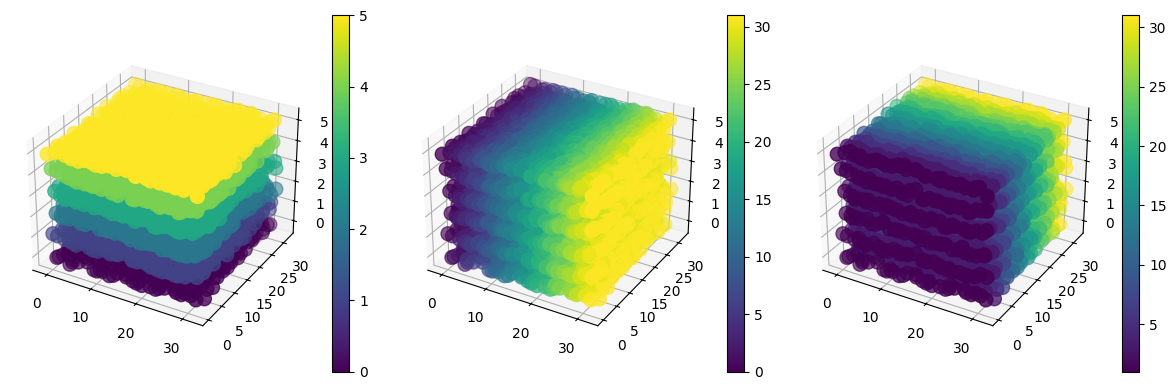

In [39]:
fig = plt.figure(figsize=(12, 4))

cats = [2, 4, 5]

for i in range(3):
  ind = cats[i]

  ax = fig.add_subplot(1, 3, i + 1, projection='3d')
  img = ax.scatter(y_[:, -2], y_[:, -1], y_[:, 2], c=y_test[:, ind], s=100)
  plt.colorbar(img)

plt.tight_layout()
plt.show()



In [40]:
reg.coef_.shape

(6, 768)

In [41]:
def cossim(a, b):
  return cosine_similarity(a[None], b[None])[0, 0]

print('size, x', cossim(reg.coef_[2], reg.coef_[4]))
print('size, y', cossim(reg.coef_[2], reg.coef_[5]))
print('x, y', cossim(reg.coef_[4], reg.coef_[5]))

size, x 0.020551186
size, y 0.008661145
x, y -0.014021194


# Animation

In [44]:
# Center of the grid
c_x, c_y = 15.5, 15.5

# 1. MORE FRAMES: This slows down the movement between steps
total_frames = 600

trajectory = np.zeros((total_frames, 6))
trajectory[:, 0] = 0 # color
trajectory[:, 1] = 2 # shape (heart)
trajectory[:, 3] = 0 # rotation

# Create a continuous spiral (6 full rotations)
theta = np.linspace(0, 6 * 2 * np.pi, total_frames)

# Continuous size from 5.99 down to 0.0 (so astype(int) steps down cleanly 5 -> 0)
continuous_size = np.linspace(5.99, 0, total_frames)
trajectory[:, 2] = continuous_size.astype(int)

# Radius scales with the continuous size (Size 5 = Radius 14, Size 0 = Radius 3)
radius = 3 + (continuous_size / 5.0) * 11

# Calculate X and Y, rounding to the nearest integer index
trajectory[:, 4] = np.clip(np.round(c_x + radius * np.cos(theta)), 0, 31).astype(int)
trajectory[:, 5] = np.clip(np.round(c_y + radius * np.sin(theta)), 0, 31).astype(int)

trajectory.shape

(600, 6)

In [45]:
x = last_hidden_state
y = targets[ind_good, :].copy().astype(float)
reg = LinearRegression().fit(x, y)
y_ = reg.predict(x)
print(y.shape, y_.shape)

subsample = 1

traj_y_true = trajectory.copy()[::subsample, np.array((2, 4, 5))]
traj_y_pred = []
traj_images = []
for ind in tqdm(trajectory[::subsample]):
  i = np.where(np.all(targets == ind, 1))[0][0]
  traj_images.append(images[i].copy())
  j = np.where(np.all(y == ind, 1))[0][0]
  traj_y_pred.append(y_[j, np.array((2, 4, 5))].copy())
traj_images = np.array(traj_images)
traj_y_pred = np.array(traj_y_pred)

print(traj_images.shape, traj_y_true.shape, traj_y_pred.shape)
print(traj_y_true[:3], traj_y_pred[:3])

(6144, 6) (6144, 6)


100%|██████████| 600/600 [00:18<00:00, 31.87it/s]

(600, 64, 64) (600, 3) (600, 3)
[[ 5. 31. 16.]
 [ 5. 31. 17.]
 [ 5. 31. 18.]] [[ 4.9192357 30.851097  15.921684 ]
 [ 5.014571  31.212933  16.748747 ]
 [ 5.0618095 30.9565    17.875214 ]]


In [47]:
num_frames = len(traj_images)

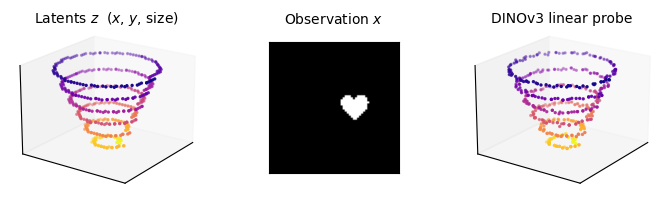

In [85]:
plot_size = 0.5
fig, axes = plt.subplots(
    1, 3, figsize=plot_size * np.array((18, 5)),
    gridspec_kw={'width_ratios': [1.3, 0.7, 1.3]},
)
for i in (0, 2):
    axes[i].remove()
    axes[i] = fig.add_subplot(1, 3, i+1, projection='3d')
ax1, ax2, ax3 = axes

for ax in (ax1, ax3):
    ax.set_xlim(-2, 33); ax.set_ylim(-2, 33); ax.set_zlim(-0.5, 5.5)
    ax.view_init(elev=20, azim=35)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_aspect('equal')

ax1.scatter(traj_y_true[:, 2], traj_y_true[:, 1], traj_y_true[:, 0],
            c=np.arange(len(traj_y_true)), cmap='plasma', s=2)
ax3.scatter(traj_y_pred[:, 2], traj_y_pred[:, 1], traj_y_pred[:, 0],
            c=np.arange(len(traj_y_pred)), cmap='plasma', s=2)
ax2.imshow(traj_images[len(traj_images) // 2], cmap='gray')

fig.canvas.draw()  # finalize layout before reading bboxes

for ax, label in [(ax1, "Latents $z$  ($x$, $y$, size)"),
                  (ax2, "Observation $x$"),
                  (ax3, "DINOv3 linear probe")]:
    bbox = ax.get_position()
    fig.text(bbox.x0 + bbox.width / 2, 0.85, label,
             ha='center', va='center')

plt.savefig('fig_hook_dsprites.png', dpi=500)  # no bbox_inches
plt.show()